In [26]:
import torch

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
from torch import nn

In [29]:
torch.__version__

'2.10.0+cpu'

In [30]:
#setup device agnostic code
device='cuda' if torch.cuda.is_available() else 'cpu'
print(f"using device:{device}")

using device:cpu


In [31]:
#create weight and bias
weight=0.7
bias=0.3

#create range values
start=0
end=1
step=0.02

#create x features and y labels
x=torch.arange(start,end,step).unsqueeze(dim=1) #squeeze creates 2 dimension tensors to avoid errors later
y= weight*x+bias

x[:10] ,y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [32]:
#split training data into 80% training and 20% testing data
split_data= int(0.8*len(x)) #80% data length for training

x_train, y_train = x[:split_data], y[:split_data]
x_test,y_test = x[split_data:],y[split_data:]

len(x_train),len(y_train),len(x_test),len(y_test)


(40, 40, 10, 10)

In [33]:
#plotting the data into graph

def plot_predictions(train_data=x_train,
                    train_label=y_train,
                    test_data=x_test,
                    test_label=y_test,
                    predictions=None):

  plt.figure(figsize=(10,7))

  #plot train data and label in blue
  plt.scatter(x_train,y_train, c='b',s=4, label="training data")

  #plot testing data and label in red
  plt.scatter(x_test,y_test, c='r',s=4,label="testing data")

  if predictions is not None:
    #plot prediction data in green (prediction are made in test data)
    plt.scatter(x_test, predictions, c='g',s=4,label="Prediction data")

  #show legend
  plt.legend(prop={"size":14});


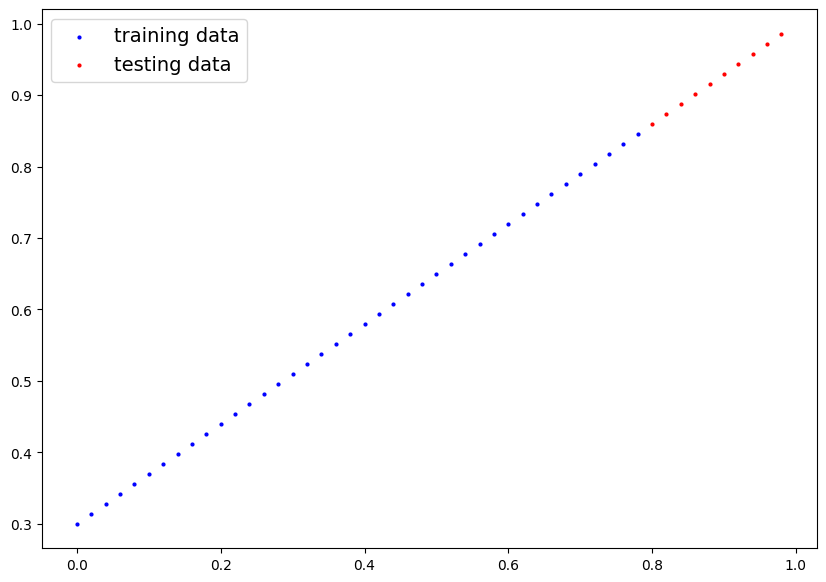

In [34]:
plot_predictions();

In [35]:
#Building a pyTorch Linear model

class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    #using nn.Linear() for creating the model parameters
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

    #define the forward competition
  def forward(self,x:torch.tensor)->torch.tensor:
      return self.linear_layer(x)

# Set the manual seed when creating the model
torch.manual_seed(42)
model_1=LinearRegressionModelV2()

model_1, model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [36]:
#lets test model device

next(model_1.parameters()).device

device(type='cpu')

In [37]:
#set the model to GPU otherwie it will default back to cpu
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [38]:
#create a loss function
loss_fn= nn.L1Loss()

#create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), #optimizes newly created model parameters
                            lr=0.01)

In [39]:
#lets start the training of pytorch model

torch.manual_seed(42)

#set the number of epoches
epoches=1000

#put the data on the device(not all model/ data only)
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)

for epoch in range(epoches):

  #training
  model_1.train() #train mode is on by default  after construction

  # 1. forward pass
  y_preds = model_1(x_train)

  #calculate the loss function
  loss = loss_fn(y_preds,y_train)

  #3. optimise the model by setting gradient descent to zero for new loop
  optimizer.zero_grad()

  #4. loss backward function
  loss.backward()

  #step the optimizer
  optimizer.step()

  #testing
  model_1.eval() #put the model in evaluation mode( inference mode)

  #1. fprward pass
  with torch.inference_mode():
    test_pred = model_1(x_test)
  #2. Calculate the loss
  test_loss = loss_fn(test_pred, y_test)

  if epoch %10==0:
    print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}" )







Epoch: 0 | Train loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 10 | Train loss: 0.4399680495262146 | Test loss: 0.4392663538455963
Epoch: 20 | Train loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch: 30 | Train loss: 0.20954827964305878 | Test loss: 0.16984674334526062
Epoch: 40 | Train loss: 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch: 50 | Train loss: 0.023886386305093765 | Test loss: 0.04784906655550003
Epoch: 60 | Train loss: 0.0199567973613739 | Test loss: 0.04580312222242355
Epoch: 70 | Train loss: 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch: 80 | Train loss: 0.013089170679450035 | Test loss: 0.029944902285933495
Epoch: 90 | Train loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch: 100 | Train loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 110 | Train loss: 0.002787243574857712 | Test loss: 0.005814164876937866
Epoch: 120 | Train loss: 0.0012645035749301314 | Test loss: 0.01380180753

In [40]:
#Find out models learned  parameters

from pprint import pprint  #pprint =preety print
print("The model learned the following values for weights and bias")
pprint(model_1.state_dict())
print("\n ANd the original values of weight and bias are:")
print(f"weights:{weight} and bias:{bias}")

The model learned the following values for weights and bias
OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

 ANd the original values of weight and bias are:
weights:0.7 and bias:0.3


In [41]:
#making predictions

#put the model into evaluation mode
model_1.eval()

#make predictions on the test data

with torch.inference_mode():
  y_preds = model_1(x_test) # Corrected: input should be x_test, not y_test

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

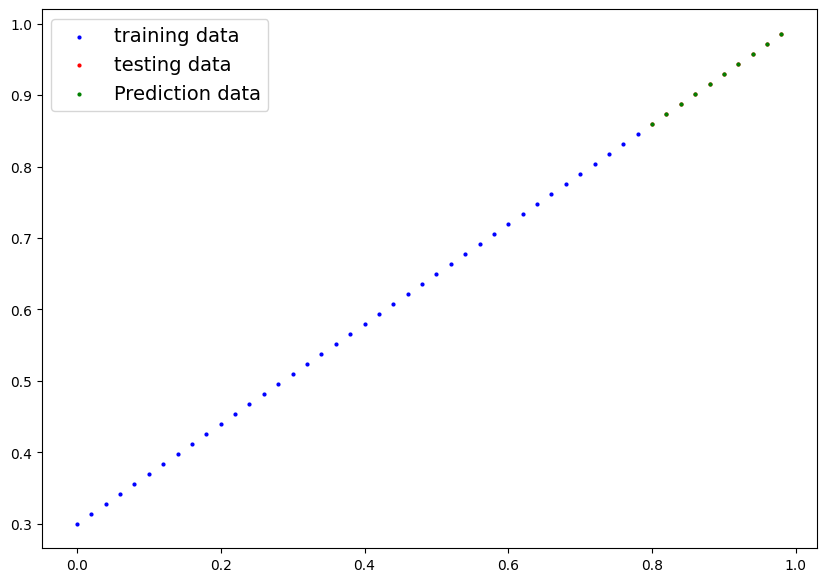

In [42]:
#plot predictions (first make sure the predictions data is inside CPU or it wont work)
#our data is alredy on cpu so we dont need to change
plot_predictions(predictions=y_preds);

In [43]:
#saving and loading a model

from pathlib import Path

#1. create models directory
model_path= Path("models")
model_path.mkdir(parents=True, exist_ok=True)

#2. create model save path
model_name = "pytorch_workflow_model"
model_save_path = model_path/model_name

#3. save the model state dict
print(f"saving model to:{model_save_path}")
torch.save(obj=model_1.state_dict(),
           f=model_save_path)

saving model to:models/pytorch_workflow_model


In [44]:
#instantiate a fresh instance of LinearRegressioModel

Loaded_Model_1  = LinearRegressionModelV2()


#Load Model state dict
Loaded_Model_1.load_state_dict(torch.load(model_save_path))

#Put model on target device
Loaded_Model_1.to(device)

print(f"Loaded Model: \n{Loaded_Model_1}")
print(f"Model on device: \n{next(Loaded_Model_1.parameters()).device}")

Loaded Model: 
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device: 
cpu


In [45]:
#Ecaluate the loaded model

Loaded_Model_1.eval()

with torch.inference_mode():
  Loaded_Model_1_preds = Loaded_Model_1(x_test)

y_preds == Loaded_Model_1_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])